[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                    Oro   Petroleo
Date                              
2020-01-02  1524.500000  61.180000
2020-01-03  1549.199951  63.049999
2020-01-06  1566.199951  63.270000
2020-01-07  1571.800049  62.700001
2020-01-08  1557.400024  59.610001


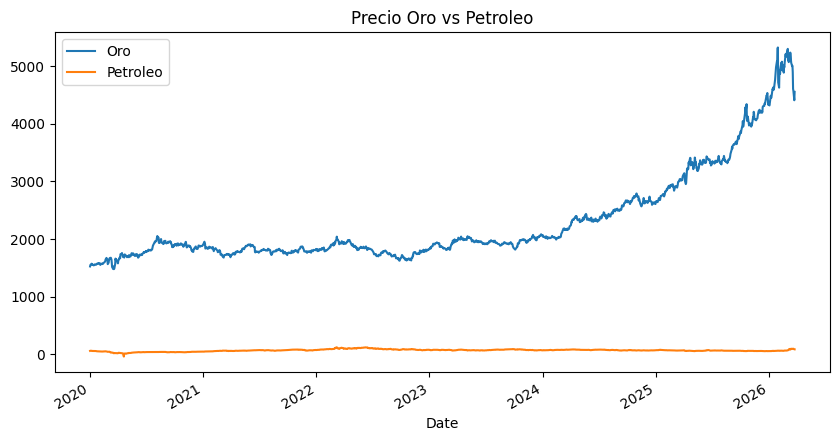

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. Descarga de datos
# ==============================

def get_data(start="2020-01-01"):
    oro = yf.download("GC=F", start=start)["Close"]
    petroleo = yf.download("CL=F", start=start)["Close"]

    data = pd.concat([oro, petroleo], axis=1)
    data.columns = ["Oro", "Petroleo"]

    return data.dropna()

# ==============================
# 2. Transformaciones
# ==============================

def compute_returns(data):
    return data.pct_change().dropna()

# ==============================
# 3. Visualización
# ==============================

def plot_prices(data):
    data.plot(title="Precio Oro vs Petroleo", figsize=(10,5))
    plt.show()

# ==============================
# 4. Ejecución
# ==============================

data = get_data()
returns = compute_returns(data)

print(data.head())
plot_prices(data)

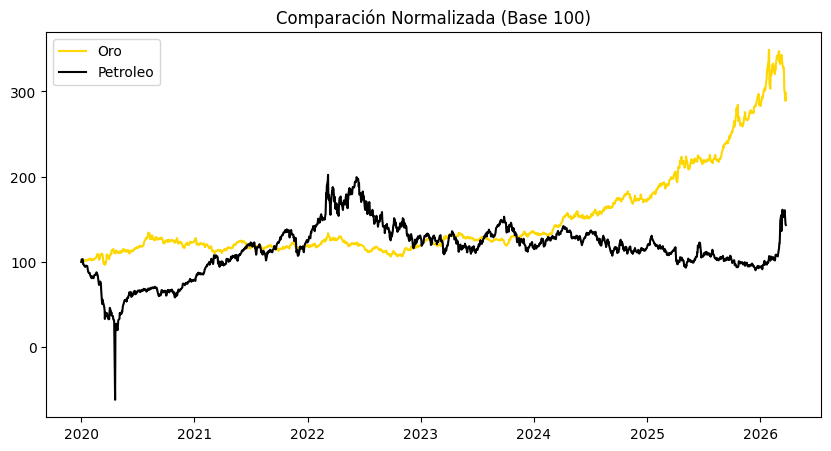

In [19]:
def normalize(data):
    return data / data.iloc[0] * 100

normalized = normalize(data)

plt.figure(figsize=(10,5))
plt.plot(normalized.index, normalized["Oro"], color="gold", label="Oro")
plt.plot(normalized.index, normalized["Petroleo"], color="black", label="Petroleo")

plt.title("Comparación Normalizada (Base 100)")
plt.legend()
plt.show()